In [10]:
#@AUTHOR-SOUPARNO

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

In [3]:
df = pd.read_excel("LLM_Usage_Trends.xlsx")

In [4]:
df.shape

(600, 30)

In [5]:
df.head()

,User_ID,Job_Role,Industry,Experience_Level,Years_of_Experience,Age_Group,Country,Company_Size,Primary_LLM_Tool,Primary_Model_Used,Secondary_LLM_Tool,Secondary_Model_Used,Subscription_Type,Monthly_Cost_USD,Usage_Frequency,Hours_Per_Week,Adoption_Date,Months_Since_Adoption,Primary_Use_Case,Secondary_Use_Case,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10,Would_Recommend,Main_Concern,Team_Also_Uses_LLM,Company_Provided_Training
0,USR0001,Data Scientist,Information Technology,Mid-Level,5.400,35-44,India,Large (1000+),DeepSeek,DeepSeek V4-Flash,NaN,NaN,Free,0,Several times a week,6.200,2025-08-16,11,Data Analysis,Research & Summarization,8,35,8.700,5,5,3,No,Job Security,No,Yes
1,USR0002,Operations Manager,Manufacturing & Operations,Lead/Managerial,18.900,35-44,India,Mid-size (201-1000),ChatGPT,GPT-5.6 Sol (Plus),Mistral (Le Chat),Mistral Large 3 (Le Chat Pro),Paid (Individual),25,Daily,13.600,2025-04-21,15,Meeting Notes & Summaries,Learning/Studying,17,44,9.000,8,9,8,Yes,Bias in Output,Yes,Yes
2,USR0003,Marketing Manager,Marketing & Advertising,Senior-Level,6.800,25-34,India,Large (1000+),Perplexity,Perplexity Pro (Sonar Pro),NaN,NaN,Paid (Individual),20,Several times a week,4.800,2023-10-10,34,Content Writing,Research & Summarization,3,32,8.700,6,6,5,Yes,Data Privacy,Yes,No
3,USR0004,Healthcare Professional,Healthcare,Mid-Level,5.400,25-34,India,Small (51-200),Gemini,Gemini 3.1 Pro,NaN,NaN,Paid (Individual),22,Weekly,2.200,2023-09-01,35,Research & Summarization,Customer Query Resolution,1,15,2.700,5,6,4,Yes,Accuracy of responses,No,No
4,USR0005,Digital Marketer,Marketing & Advertising,Mid-Level,3.200,35-44,United States,Startup (1-50),ChatGPT,GPT-5.6 Sol (Business),NaN,NaN,Enterprise/Team,35,Daily,19.600,2023-11-02,33,Content Writing,Translation,27,47,10.100,5,5,5,Yes,Data Privacy,Yes,Yes


In [6]:
df.head(-80)

,User_ID,Job_Role,Industry,Experience_Level,Years_of_Experience,Age_Group,Country,Company_Size,Primary_LLM_Tool,Primary_Model_Used,Secondary_LLM_Tool,Secondary_Model_Used,Subscription_Type,Monthly_Cost_USD,Usage_Frequency,Hours_Per_Week,Adoption_Date,Months_Since_Adoption,Primary_Use_Case,Secondary_Use_Case,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10,Would_Recommend,Main_Concern,Team_Also_Uses_LLM,Company_Provided_Training
0,USR0001,Data Scientist,Information Technology,Mid-Level,5.400,35-44,India,Large (1000+),DeepSeek,DeepSeek V4-Flash,NaN,NaN,Free,0,Several times a week,6.200,2025-08-16,11,Data Analysis,Research & Summarization,8,35,8.700,5,5,3,No,Job Security,No,Yes
1,USR0002,Operations Manager,Manufacturing & Operations,Lead/Managerial,18.900,35-44,India,Mid-size (201-1000),ChatGPT,GPT-5.6 Sol (Plus),Mistral (Le Chat),Mistral Large 3 (Le Chat Pro),Paid (Individual),25,Daily,13.600,2025-04-21,15,Meeting Notes & Summaries,Learning/Studying,17,44,9.000,8,9,8,Yes,Bias in Output,Yes,Yes
2,USR0003,Marketing Manager,Marketing & Advertising,Senior-Level,6.800,25-34,India,Large (1000+),Perplexity,Perplexity Pro (Sonar Pro),NaN,NaN,Paid (Individual),20,Several times a week,4.800,2023-10-10,34,Content Writing,Research & Summarization,3,32,8.700,6,6,5,Yes,Data Privacy,Yes,No
3,USR0004,Healthcare Professional,Healthcare,Mid-Level,5.400,25-34,India,Small (51-200),Gemini,Gemini 3.1 Pro,NaN,NaN,Paid (Individual),22,Weekly,2.200,2023-09-01,35,Research & Summarization,Customer Query Resolution,1,15,2.700,5,6,4,Yes,Accuracy of responses,No,No
4,USR0005,Digital Marketer,Marketing & Advertising,Mid-Level,3.200,35-44,United States,Startup (1-50),ChatGPT,GPT-5.6 Sol (Business),NaN,NaN,Enterprise/Team,35,Daily,19.600,2023-11-02,33,Content Writing,Translation,27,47,10.100,5,5,5,Yes,Data Privacy,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,USR0516,Customer Support Executive,BPO/Customer Service,Entry-Level,0.800,25-34,United States,Mid-size (201-1000),ChatGPT,GPT-5.5 Instant,Qwen,Qwen3 32B,Free,0,Daily,19.400,2022-12-03,44,Customer Query Resolution,Translation,26,63,18.900,7,7,6,Yes,Bias in Output,Yes,No
516,USR0517,Software Engineer,Information Technology,Senior-Level,9.900,18-24,Canada,Mid-size (201-1000),Claude,Claude Haiku 4.5,Meta AI (Llama),Llama 4 Scout,Free,0,Weekly,2.200,2023-07-01,37,Coding & Debugging,Meeting Notes & Summaries,6,25,7.400,10,10,7,Yes,NaN,Yes,No
517,USR0518,UI/UX Designer,Information Technology,Lead/Managerial,14.900,35-44,Canada,Small (51-200),ChatGPT,GPT-5.5 Instant,Gemini,Gemini 3.5 Flash,Free,0,Weekly,3.000,2025-09-02,11,Image/Design Generation,Coding & Debugging,1,15,2.900,6,6,4,Yes,Data Privacy,Yes,No
518,USR0519,Student,Education,Mid-Level,5.700,35-44,India,Large (1000+),Grok,Grok 4.5 (SuperGrok),NaN,NaN,Paid (Individual),20,Several times a week,8.600,2024-02-18,29,Learning/Studying,Customer Query Resolution,12,29,5.400,6,5,4,Yes,Data Privacy,Yes,No


In [7]:
df.tail(-10)

,User_ID,Job_Role,Industry,Experience_Level,Years_of_Experience,Age_Group,Country,Company_Size,Primary_LLM_Tool,Primary_Model_Used,Secondary_LLM_Tool,Secondary_Model_Used,Subscription_Type,Monthly_Cost_USD,Usage_Frequency,Hours_Per_Week,Adoption_Date,Months_Since_Adoption,Primary_Use_Case,Secondary_Use_Case,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10,Would_Recommend,Main_Concern,Team_Also_Uses_LLM,Company_Provided_Training
10,USR0011,UI/UX Designer,Information Technology,Senior-Level,6.600,18-24,United States,Large (1000+),Claude,Claude Sonnet 5,NaN,NaN,Paid (Individual),20,Weekly,1.100,2025-03-28,16,Image/Design Generation,Content Writing,1,11,2.300,6,5,3,No,Data Privacy,No,No
11,USR0012,HR Manager,Human Resources,Entry-Level,0.500,35-44,Singapore,Startup (1-50),ChatGPT,GPT-5.5 Instant,NaN,NaN,Free,0,Monthly,1.000,2024-07-03,25,Email/Document Drafting,Image/Design Generation,3,15,3.300,6,4,3,Yes,Accuracy of responses,Yes,No
12,USR0013,Content Writer,Media & Publishing,Senior-Level,8.400,25-34,United States,Large (1000+),Grok,Grok 4 Mini,Microsoft Copilot,Copilot (GPT-5.5 based),Free,0,Daily,14.900,2023-07-20,36,Content Writing,Image/Design Generation,17,38,12.400,7,7,3,Yes,NaN,No,No
13,USR0014,Graphic Designer,Media & Publishing,Senior-Level,9.900,35-44,India,Mid-size (201-1000),Claude,Claude Sonnet 5,NaN,NaN,Paid (Individual),20,Several times a week,5.600,2023-02-17,42,Image/Design Generation,Content Writing,2,30,6.200,4,5,3,No,Job Security,Yes,No
14,USR0015,Student,Education,Mid-Level,3.300,25-34,Singapore,Mid-size (201-1000),DeepSeek,DeepSeek V4-Pro (Expert Mode),Cohere (Command),Command R,Paid (Individual),20,Daily,16.300,2024-09-04,23,Learning/Studying,Meeting Notes & Summaries,21,57,10.200,9,9,5,Yes,NaN,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,USR0596,Business Analyst,Consulting,Mid-Level,2.200,25-34,India,Startup (1-50),Perplexity,Perplexity (Sonar Auto),Meta AI (Llama),Llama 4 Scout,Free,0,Daily,19.000,2026-04-22,3,Data Analysis,Research & Summarization,18,43,14.400,6,7,8,Yes,Job Security,Yes,No
596,USR0597,Sales Executive,Sales & Retail,Senior-Level,12.000,18-24,United Kingdom,Mid-size (201-1000),ChatGPT,GPT-5.6 Sol (Plus),NaN,NaN,Paid (Individual),20,Monthly,1.900,2025-12-01,8,Email/Document Drafting,Content Writing,2,11,1.800,7,5,4,Yes,Job Security,Yes,Yes
597,USR0598,Data Scientist,Information Technology,Senior-Level,9.700,35-44,India,Small (51-200),Grok,Grok 4 Mini,Claude,Claude Haiku 4.5,Free,0,Several times a week,6.000,2025-01-02,19,Data Analysis,Research & Summarization,12,42,11.800,5,3,3,No,Data Privacy,No,Yes
598,USR0599,Business Analyst,Consulting,Lead/Managerial,16.300,35-44,UAE,Large (1000+),ChatGPT,GPT-5.6 Sol (Plus),Grok,Grok 4 Mini,Paid (Individual),25,Daily,14.400,2025-10-23,9,Data Analysis,Coding & Debugging,15,52,8.600,10,7,6,Yes,Data Privacy,Yes,Yes


In [8]:
num_cols = ["Years_of_Experience", "Monthly_Cost_USD", "Hours_Per_Week", "Months_Since_Adoption",
            "Tasks_Automated_Per_Week", "Productivity_Gain_Percent", "Time_Saved_Hours_Per_Week",
            "Accuracy_Satisfaction_Score_1to10", "Overall_Satisfaction_Score_1to10", "Trust_Level_1to10"]

cat_cols = ["Job_Role", "Industry", "Experience_Level", "Age_Group", "Country", "Company_Size",
            "Primary_LLM_Tool", "Primary_Model_Used", "Secondary_LLM_Tool", "Subscription_Type",
            "Usage_Frequency", "Primary_Use_Case", "Secondary_Use_Case", "Would_Recommend",
            "Main_Concern", "Team_Also_Uses_LLM", "Company_Provided_Training"]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Years_of_Experience', 'Monthly_Cost_USD', 'Hours_Per_Week', 'Months_Since_Adoption', 'Tasks_Automated_Per_Week', 'Productivity_Gain_Percent', 'Time_Saved_Hours_Per_Week', 'Accuracy_Satisfaction_Score_1to10', 'Overall_Satisfaction_Score_1to10', 'Trust_Level_1to10']
Categorical columns: ['Job_Role', 'Industry', 'Experience_Level', 'Age_Group', 'Country', 'Company_Size', 'Primary_LLM_Tool', 'Primary_Model_Used', 'Secondary_LLM_Tool', 'Subscription_Type', 'Usage_Frequency', 'Primary_Use_Case', 'Secondary_Use_Case', 'Would_Recommend', 'Main_Concern', 'Team_Also_Uses_LLM', 'Company_Provided_Training']


In [9]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("-"*50)
print("\nData types:")
print(df.dtypes)
print("-"*50)
print("\nUnique values per column:")
print(df.nunique())

Shape: (600, 30)

Column names:
 ['User_ID', 'Job_Role', 'Industry', 'Experience_Level', 'Years_of_Experience', 'Age_Group', 'Country', 'Company_Size', 'Primary_LLM_Tool', 'Primary_Model_Used', 'Secondary_LLM_Tool', 'Secondary_Model_Used', 'Subscription_Type', 'Monthly_Cost_USD', 'Usage_Frequency', 'Hours_Per_Week', 'Adoption_Date', 'Months_Since_Adoption', 'Primary_Use_Case', 'Secondary_Use_Case', 'Tasks_Automated_Per_Week', 'Productivity_Gain_Percent', 'Time_Saved_Hours_Per_Week', 'Accuracy_Satisfaction_Score_1to10', 'Overall_Satisfaction_Score_1to10', 'Trust_Level_1to10', 'Would_Recommend', 'Main_Concern', 'Team_Also_Uses_LLM', 'Company_Provided_Training']
--------------------------------------------------

Data types:
User_ID                                  str
Job_Role                                 str
Industry                                 str
Experience_Level                         str
Years_of_Experience                  float64
Age_Group                                st

In [11]:
print("First pass info:")
print(df.info())

First pass info:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   User_ID                            600 non-null    str    
 1   Job_Role                           600 non-null    str    
 2   Industry                           600 non-null    str    
 3   Experience_Level                   600 non-null    str    
 4   Years_of_Experience                600 non-null    float64
 5   Age_Group                          600 non-null    str    
 6   Country                            600 non-null    str    
 7   Company_Size                       600 non-null    str    
 8   Primary_LLM_Tool                   600 non-null    str    
 9   Primary_Model_Used                 600 non-null    str    
 10  Secondary_LLM_Tool                 332 non-null    str    
 11  Secondary_Model_Used               332 non-null    s

In [13]:
# descriptive statistics
df[num_cols].describe()

,Years_of_Experience,Monthly_Cost_USD,Hours_Per_Week,Months_Since_Adoption,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10
count,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000
mean,5.953,13.670,7.662,23.365,9.862,29.970,7.728,6.412,6.225,4.748
std,4.941,12.883,5.776,12.066,7.731,15.586,4.501,1.607,1.889,2.028
min,0.000,0.000,0.100,2.000,1.000,3.000,0.600,2.000,2.000,1.000
25%,1.900,0.000,2.200,14.000,3.000,18.000,4.200,5.000,5.000,3.000
50%,4.800,20.000,6.600,24.000,8.000,28.000,6.900,6.000,6.000,5.000
75%,9.025,22.000,11.525,34.000,16.000,41.000,10.525,7.000,8.000,6.000
max,19.900,40.000,20.000,44.000,31.000,75.000,23.800,10.000,10.000,10.000


In [16]:
#Missing values

In [17]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)


In [18]:
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

print("Missing values summary:")
missing_summary

Missing values summary:


,missing_count,missing_percent
Secondary_LLM_Tool,268,44.670
Secondary_Model_Used,268,44.670
Main_Concern,89,14.830
Industry,0,0.000
User_ID,0,0.000
Experience_Level,0,0.000
Age_Group,0,0.000
Years_of_Experience,0,0.000
Country,0,0.000
Company_Size,0,0.000


In [19]:
df.isnull().sum()

User_ID                                0
Job_Role                               0
Industry                               0
Experience_Level                       0
Years_of_Experience                    0
Age_Group                              0
Country                                0
Company_Size                           0
Primary_LLM_Tool                       0
Primary_Model_Used                     0
Secondary_LLM_Tool                   268
Secondary_Model_Used                 268
Subscription_Type                      0
Monthly_Cost_USD                       0
Usage_Frequency                        0
Hours_Per_Week                         0
Adoption_Date                          0
Months_Since_Adoption                  0
Primary_Use_Case                       0
Secondary_Use_Case                     0
Tasks_Automated_Per_Week               0
Productivity_Gain_Percent              0
Time_Saved_Hours_Per_Week              0
Accuracy_Satisfaction_Score_1to10      0
Overall_Satisfac

In [20]:
#DUPLICATES

In [21]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [22]:
# User_ID should always be unique
print("Duplicate User_IDs:", df["User_ID"].duplicated().sum())

Duplicate User_IDs: 0


In [23]:
expected_types = {
    "Years_of_Experience": "float64",
    "Monthly_Cost_USD": "int64",
    "Hours_Per_Week": "float64",
    "Months_Since_Adoption": "int64",
    "Job_Role": "object",
    "Primary_LLM_Tool": "object",
    "Adoption_Date": "object"
}

In [24]:
print("Data type validation:")
for col, expected in expected_types.items():
    actual = str(df[col].dtype)
    status = "OK" if actual == expected else "MISMATCH"
    print(f"{col}: expected={expected}, actual={actual} -> {status}")

Data type validation:
Years_of_Experience: expected=float64, actual=float64 -> OK
Monthly_Cost_USD: expected=int64, actual=int64 -> OK
Hours_Per_Week: expected=float64, actual=float64 -> OK
Months_Since_Adoption: expected=int64, actual=int64 -> OK
Job_Role: expected=object, actual=str -> MISMATCH
Primary_LLM_Tool: expected=object, actual=str -> MISMATCH
Adoption_Date: expected=object, actual=str -> MISMATCH


In [25]:
# convert Adoption_Date to a real datetime for time-based analysis later
df["Adoption_Date"] = pd.to_datetime(df["Adoption_Date"])
df["Adoption_Date"].dtype

dtype('<M8[us]')

In [26]:
#Numerical features


In [27]:
print("Mean:")
print(df[num_cols].mean())
print("-"*50)
print("Median:")
print(df[num_cols].median())
print("-"*50)
print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
Years_of_Experience                  5.953
Monthly_Cost_USD                    13.670
Hours_Per_Week                       7.662
Months_Since_Adoption               23.365
Tasks_Automated_Per_Week             9.862
Productivity_Gain_Percent           29.970
Time_Saved_Hours_Per_Week            7.728
Accuracy_Satisfaction_Score_1to10    6.412
Overall_Satisfaction_Score_1to10     6.225
Trust_Level_1to10                    4.748
dtype: float64
--------------------------------------------------
Median:
Years_of_Experience                  4.800
Monthly_Cost_USD                    20.000
Hours_Per_Week                       6.600
Months_Since_Adoption               24.000
Tasks_Automated_Per_Week             8.000
Productivity_Gain_Percent           28.000
Time_Saved_Hours_Per_Week            6.900
Accuracy_Satisfaction_Score_1to10    6.000
Overall_Satisfaction_Score_1to10     6.000
Trust_Level_1to10                    5.000
dtype: float64
---------------------------------------------

In [28]:
#Spread

In [29]:
print("Variance:")
print(df[num_cols].var())
print("-"*50)
print("Standard Deviation:")
print(df[num_cols].std())

Variance:
Years_of_Experience                  24.415
Monthly_Cost_USD                    165.984
Hours_Per_Week                       33.362
Months_Since_Adoption               145.581
Tasks_Automated_Per_Week             59.769
Productivity_Gain_Percent           242.937
Time_Saved_Hours_Per_Week            20.259
Accuracy_Satisfaction_Score_1to10     2.583
Overall_Satisfaction_Score_1to10      3.567
Trust_Level_1to10                     4.112
dtype: float64
--------------------------------------------------
Standard Deviation:
Years_of_Experience                  4.941
Monthly_Cost_USD                    12.883
Hours_Per_Week                       5.776
Months_Since_Adoption               12.066
Tasks_Automated_Per_Week             7.731
Productivity_Gain_Percent           15.586
Time_Saved_Hours_Per_Week            4.501
Accuracy_Satisfaction_Score_1to10    1.607
Overall_Satisfaction_Score_1to10     1.889
Trust_Level_1to10                    2.028
dtype: float64


In [30]:
# Skewness & kurtosis

In [31]:
print("Skewness:")
print(df[num_cols].skew())
print("\nKurtosis:")
print(df[num_cols].kurtosis())

Skewness:
Years_of_Experience                  0.933
Monthly_Cost_USD                     0.208
Hours_Per_Week                       0.530
Months_Since_Adoption               -0.072
Tasks_Automated_Per_Week             0.664
Productivity_Gain_Percent            0.388
Time_Saved_Hours_Per_Week            0.702
Accuracy_Satisfaction_Score_1to10   -0.049
Overall_Satisfaction_Score_1to10    -0.145
Trust_Level_1to10                    0.156
dtype: float64

Kurtosis:
Years_of_Experience                  0.093
Monthly_Cost_USD                    -1.280
Hours_Per_Week                      -0.910
Months_Since_Adoption               -1.143
Tasks_Automated_Per_Week            -0.571
Productivity_Gain_Percent           -0.533
Time_Saved_Hours_Per_Week            0.026
Accuracy_Satisfaction_Score_1to10   -0.202
Overall_Satisfaction_Score_1to10    -0.490
Trust_Level_1to10                   -0.348
dtype: float64


In [32]:
#Histograms


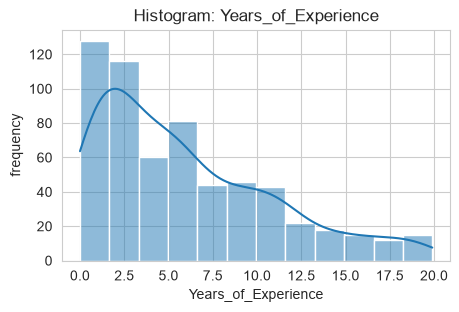

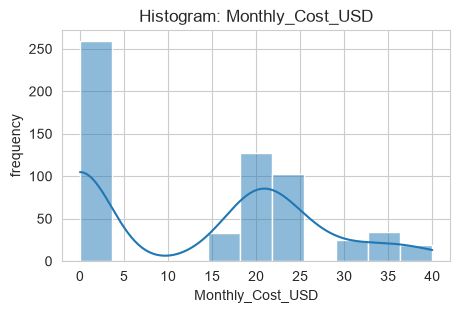

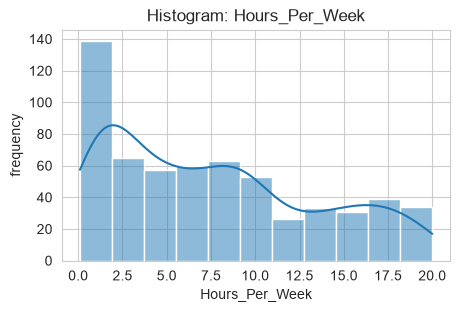

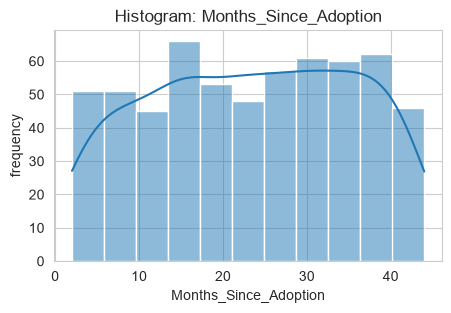

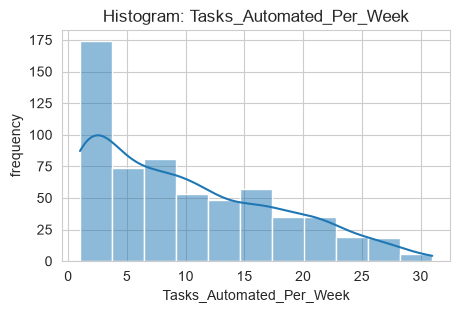

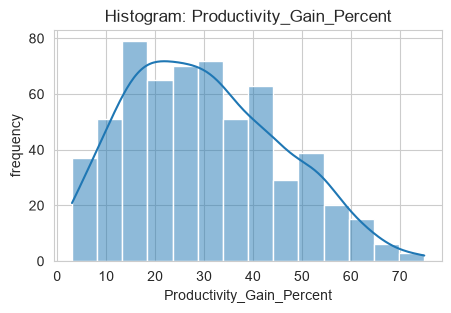

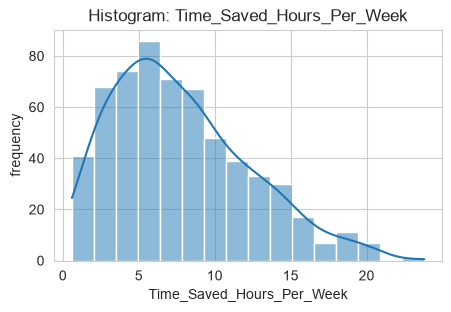

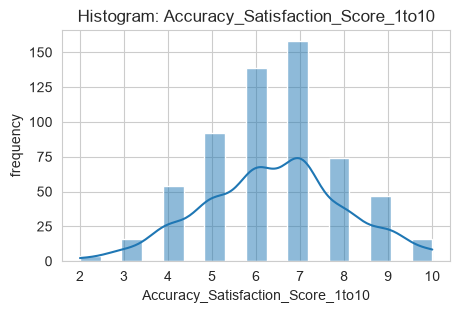

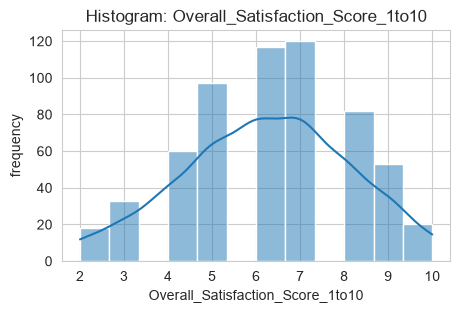

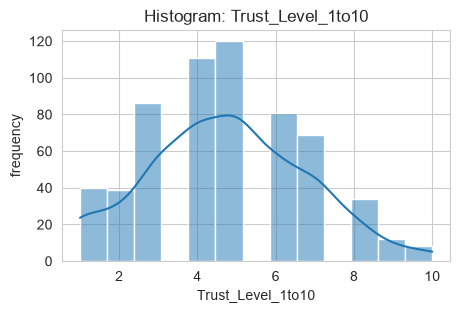

In [33]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

In [34]:
# Boxplots (outlier check)

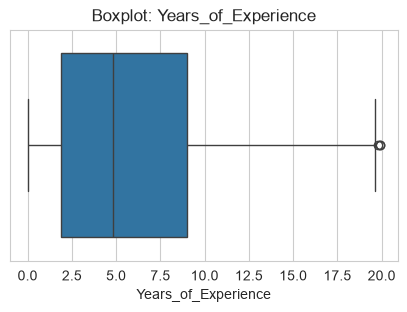

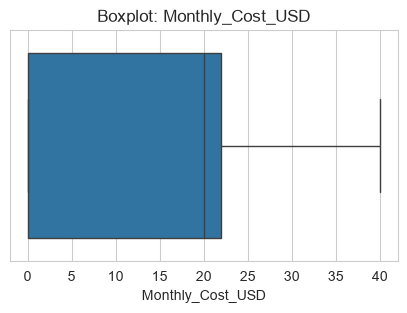

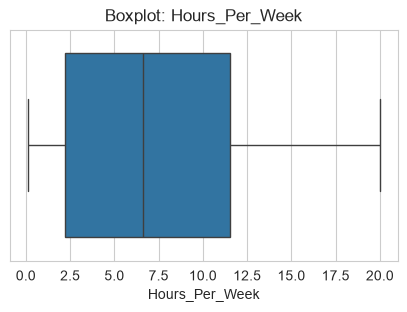

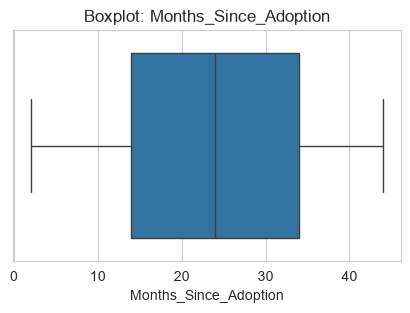

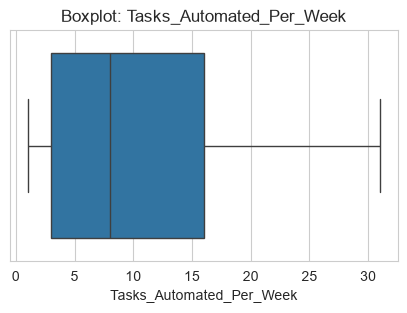

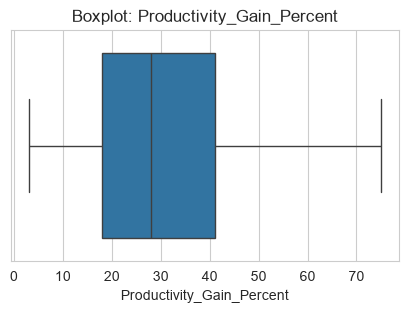

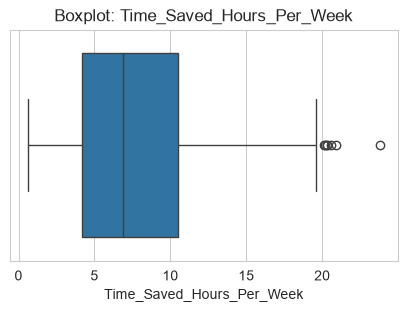

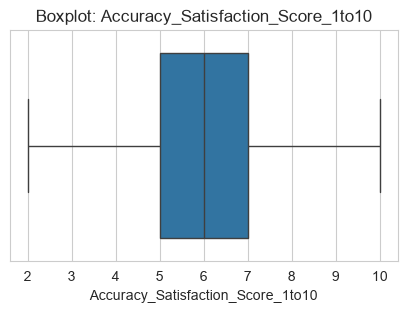

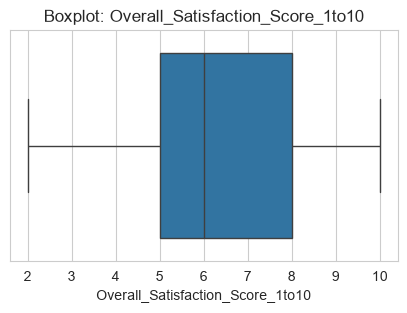

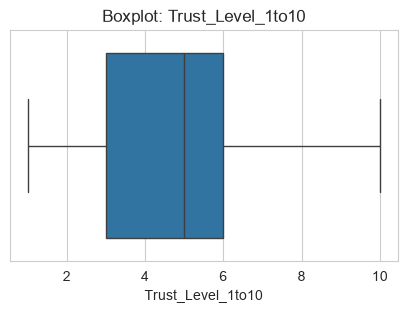

In [35]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

In [36]:
#Frequency tables

In [37]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True).round(3))
    print("-"*50)

Frequency table for Job_Role
Job_Role
Digital Marketer              39
UI/UX Designer                39
Healthcare Professional       37
Graphic Designer              36
Research Analyst              35
Legal Associate               34
Content Writer                32
Customer Support Executive    31
Sales Executive               30
Data Scientist                29
Marketing Manager             29
HR Manager                    29
Financial Analyst             28
Operations Manager            27
Business Analyst              27
Software Engineer             26
Product Manager               25
Student                       24
Teacher/Educator              23
Recruiter                     20
Name: count, dtype: int64
Proportion for Job_Role
Job_Role
Digital Marketer             0.065
UI/UX Designer               0.065
Healthcare Professional      0.062
Graphic Designer             0.060
Research Analyst             0.058
Legal Associate              0.057
Content Writer               0.05

In [38]:
#Countplots


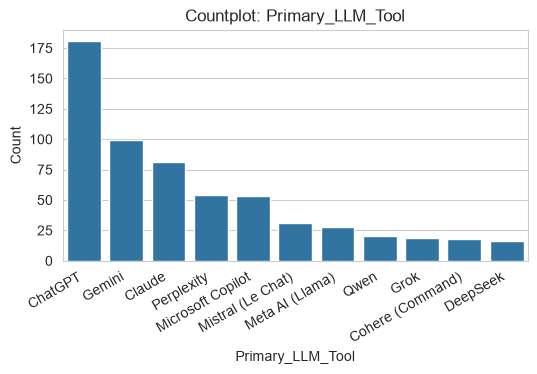

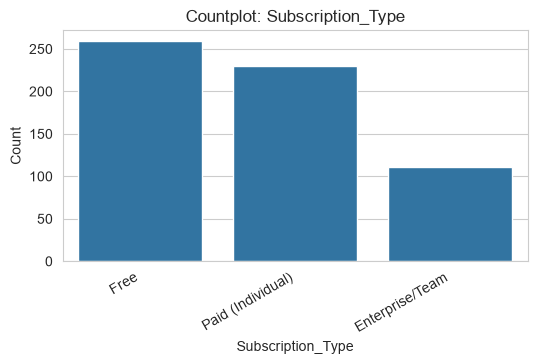

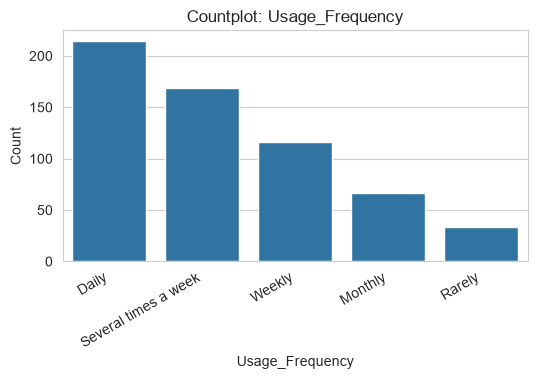

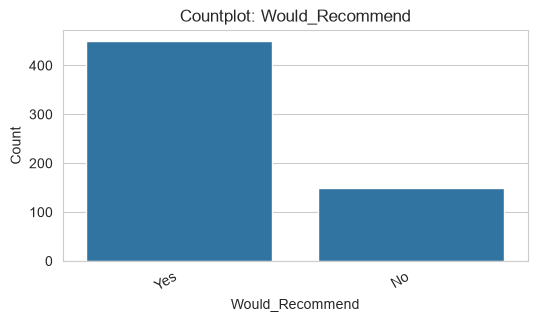

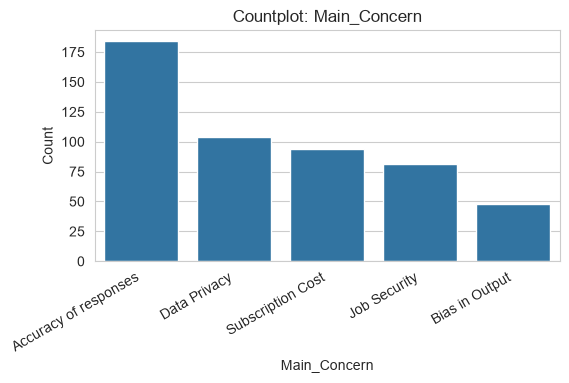

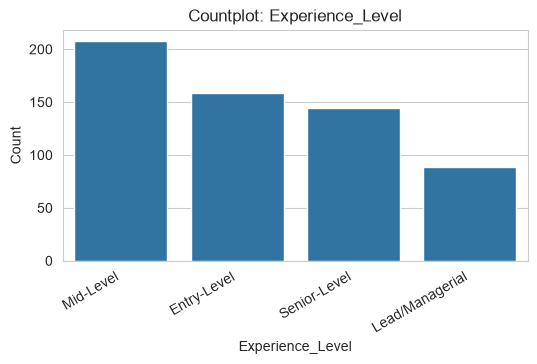

In [39]:
top_level_cats = ["Primary_LLM_Tool", "Subscription_Type", "Usage_Frequency",
                   "Would_Recommend", "Main_Concern", "Experience_Level"]

for col in top_level_cats:
    plt.figure(figsize=(6, 3))
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order)
    plt.title(f"Countplot: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.show()

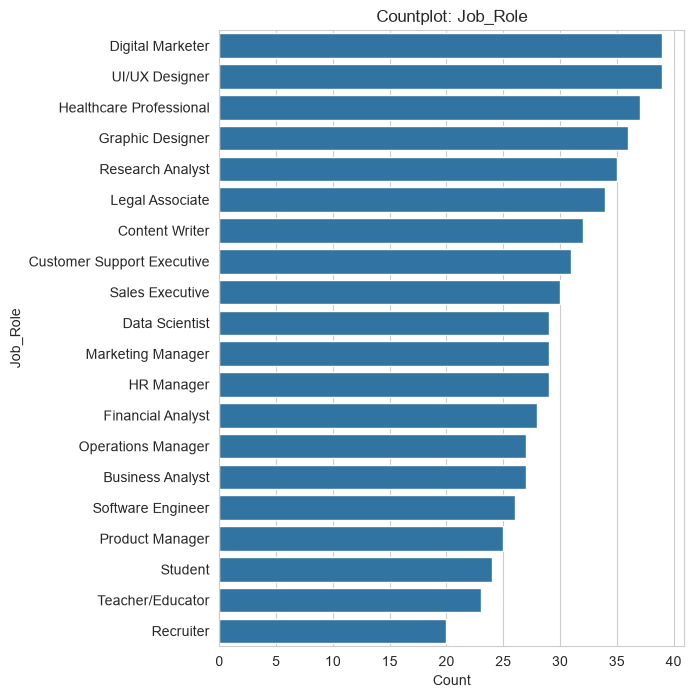

In [40]:
# Job_Role has 20 categories 
plt.figure(figsize=(6, 8))
order = df["Job_Role"].value_counts().index
sns.countplot(y=df["Job_Role"], order=order)
plt.title("Countplot: Job_Role")
plt.xlabel("Count")
plt.ylabel("Job_Role")
plt.show()

In [43]:
# Scatter plots

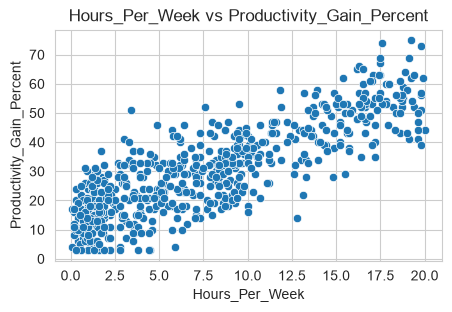

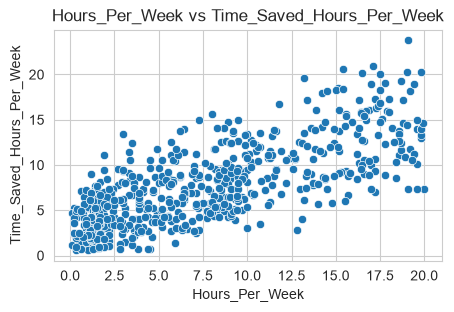

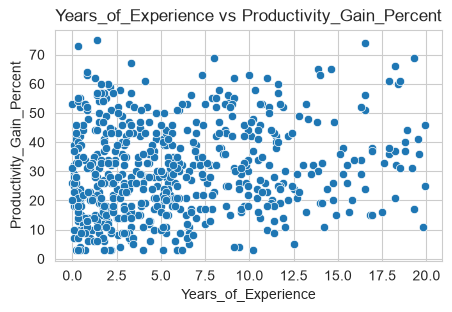

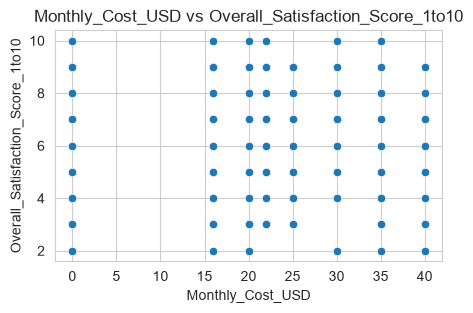

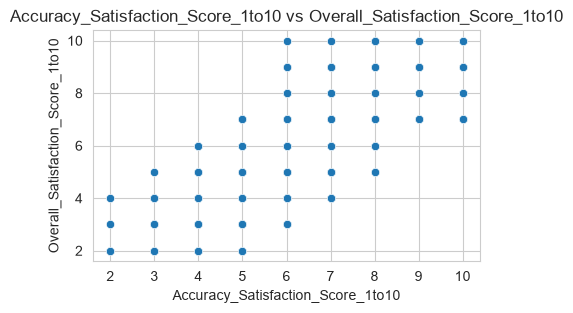

In [44]:
num_pairs = [
    ("Hours_Per_Week", "Productivity_Gain_Percent"),
    ("Hours_Per_Week", "Time_Saved_Hours_Per_Week"),
    ("Years_of_Experience", "Productivity_Gain_Percent"),
    ("Monthly_Cost_USD", "Overall_Satisfaction_Score_1to10"),
    ("Accuracy_Satisfaction_Score_1to10", "Overall_Satisfaction_Score_1to10")
]

for x, y in num_pairs:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [45]:
#Correlation matrix

In [46]:
print("Correlation Matrix")
df[num_cols].corr()

Correlation Matrix


,Years_of_Experience,Monthly_Cost_USD,Hours_Per_Week,Months_Since_Adoption,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10
Years_of_Experience,1.000,0.022,0.018,0.027,0.030,0.179,0.154,-0.014,-0.038,-0.048
Monthly_Cost_USD,0.022,1.000,-0.026,-0.013,-0.016,0.004,-0.017,-0.109,-0.111,-0.110
Hours_Per_Week,0.018,-0.026,1.000,0.030,0.930,0.833,0.746,0.064,0.056,0.073
Months_Since_Adoption,0.027,-0.013,0.030,1.000,0.005,0.022,0.040,0.020,0.042,0.025
Tasks_Automated_Per_Week,0.030,-0.016,0.930,0.005,1.000,0.788,0.717,0.075,0.064,0.070
Productivity_Gain_Percent,0.179,0.004,0.833,0.022,0.788,1.000,0.896,0.040,0.030,0.045
Time_Saved_Hours_Per_Week,0.154,-0.017,0.746,0.040,0.717,0.896,1.000,0.039,0.042,0.071
Accuracy_Satisfaction_Score_1to10,-0.014,-0.109,0.064,0.020,0.075,0.040,0.039,1.000,0.769,0.591
Overall_Satisfaction_Score_1to10,-0.038,-0.111,0.056,0.042,0.064,0.030,0.042,0.769,1.000,0.775
Trust_Level_1to10,-0.048,-0.110,0.073,0.025,0.070,0.045,0.071,0.591,0.775,1.000


In [47]:
print("Pearson correlation with Productivity_Gain_Percent:")
for col in num_cols:
    if col != "Productivity_Gain_Percent":
        r, p = pearsonr(df[col], df["Productivity_Gain_Percent"])
        print(f"{col}: r={r:.3f}, p={p:.3g}")

Pearson correlation with Productivity_Gain_Percent:
Years_of_Experience: r=0.179, p=9.79e-06
Monthly_Cost_USD: r=0.004, p=0.916
Hours_Per_Week: r=0.833, p=8.79e-156
Months_Since_Adoption: r=0.022, p=0.585
Tasks_Automated_Per_Week: r=0.788, p=4.82e-128
Time_Saved_Hours_Per_Week: r=0.896, p=8.16e-213
Accuracy_Satisfaction_Score_1to10: r=0.040, p=0.325
Overall_Satisfaction_Score_1to10: r=0.030, p=0.456
Trust_Level_1to10: r=0.045, p=0.275


In [48]:
#Numerical vs Categorical

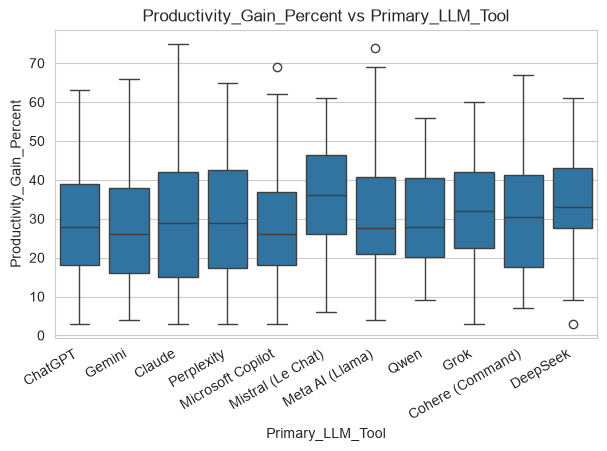

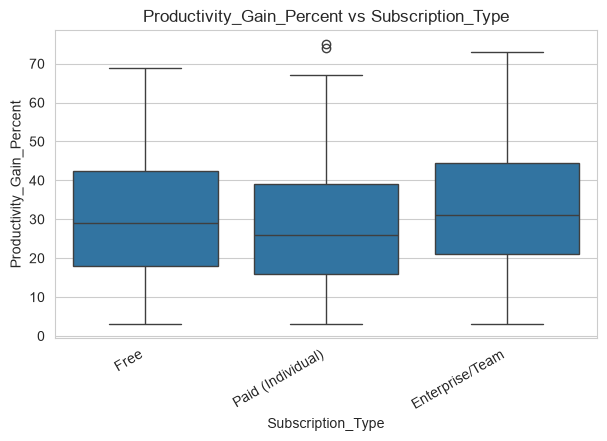

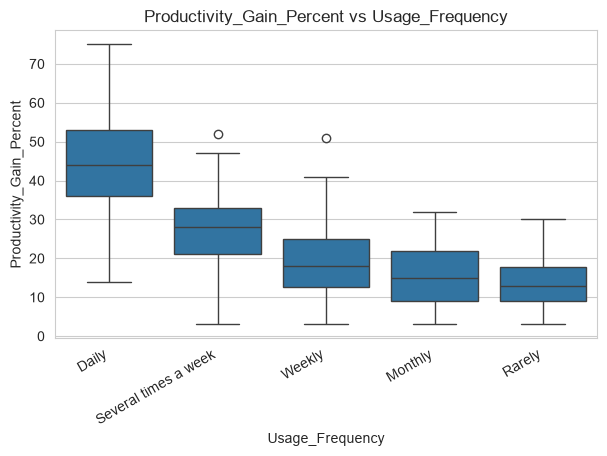

In [49]:
for cat in ["Primary_LLM_Tool", "Subscription_Type", "Usage_Frequency"]:
    plt.figure(figsize=(7, 4))
    order = df[cat].value_counts().index
    sns.boxplot(x=df[cat], y=df["Productivity_Gain_Percent"], order=order)
    plt.title(f"Productivity_Gain_Percent vs {cat}")
    plt.xlabel(cat)
    plt.ylabel("Productivity_Gain_Percent")
    plt.xticks(rotation=30, ha="right")
    plt.show()

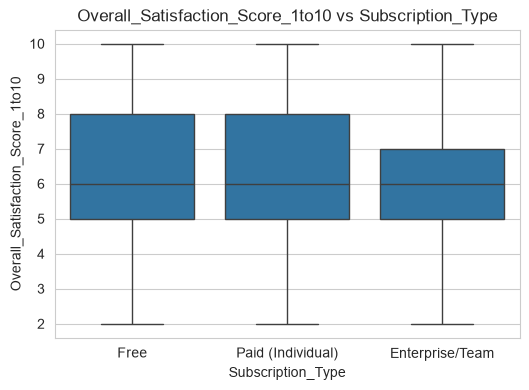

In [50]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Subscription_Type"], y=df["Overall_Satisfaction_Score_1to10"])
plt.title("Overall_Satisfaction_Score_1to10 vs Subscription_Type")
plt.show()

In [51]:
#GROUPED STATS

In [52]:
df[num_cols + ["Primary_LLM_Tool"]].groupby("Primary_LLM_Tool").mean().sort_values(
    "Productivity_Gain_Percent", ascending=False
)

,Years_of_Experience,Monthly_Cost_USD,Hours_Per_Week,Months_Since_Adoption,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Time_Saved_Hours_Per_Week,Accuracy_Satisfaction_Score_1to10,Overall_Satisfaction_Score_1to10,Trust_Level_1to10
Primary_LLM_Tool,,,,,,,,,,
Mistral (Le Chat),7.729,15.516,9.245,22.258,11.774,37.226,10.132,6.710,6.452,5.129
DeepSeek,4.556,13.625,8.669,23.312,10.250,33.938,8.481,6.938,7.125,5.250
Grok,6.174,13.842,8.568,21.737,11.579,32.105,8.295,6.579,6.474,4.684
Meta AI (Llama),7.493,6.643,8.482,23.679,10.429,31.750,7.854,6.893,6.643,5.071
Perplexity,6.065,16.278,7.778,22.259,10.130,30.963,8.430,6.537,6.593,5.056
Cohere (Command),5.556,14.889,8.194,20.167,11.167,30.889,7.511,6.944,6.722,5.056
Claude,5.435,15.346,8.088,22.741,10.185,30.160,7.678,5.790,5.580,4.235
ChatGPT,5.387,12.895,7.397,24.072,9.431,28.956,7.434,6.591,6.326,4.829
Qwen,6.950,8.850,7.365,22.800,9.600,28.500,6.915,6.750,6.700,5.050


In [53]:
for category in ["Subscription_Type", "Usage_Frequency", "Experience_Level"]:
    print(df[num_cols + [category]].groupby(category).mean())
    print("-"*50)

                   Years_of_Experience  Monthly_Cost_USD  Hours_Per_Week  \
Subscription_Type                                                          
Enterprise/Team                  6.199            31.757           8.299   
Free                             5.862             0.000           8.057   
Paid (Individual)                5.936            20.335           6.910   

                   Months_Since_Adoption  Tasks_Automated_Per_Week  \
Subscription_Type                                                    
Enterprise/Team                   23.234                    10.694   
Free                              23.552                    10.351   
Paid (Individual)                 23.217                     8.909   

                   Productivity_Gain_Percent  Time_Saved_Hours_Per_Week  \
Subscription_Type                                                         
Enterprise/Team                       32.369                      8.268   
Free                                  30.38

In [54]:
#Categorical vs Categorical

In [55]:
print("Crosstab: Primary_LLM_Tool vs Subscription_Type")
pd.crosstab(df["Primary_LLM_Tool"], df["Subscription_Type"])

Crosstab: Primary_LLM_Tool vs Subscription_Type


Subscription_Type,Enterprise/Team,Free,Paid (Individual)
Primary_LLM_Tool,,,
ChatGPT,28,82,71
Claude,20,33,28
Cohere (Command),3,7,8
DeepSeek,3,6,7
Gemini,21,40,38
Grok,2,8,9
Meta AI (Llama),1,19,8
Microsoft Copilot,10,22,21
Mistral (Le Chat),6,10,15


In [56]:
print("Crosstab: Job_Role vs Primary_LLM_Tool (top 5 roles)")
top_roles = df["Job_Role"].value_counts().head(5).index
pd.crosstab(df[df["Job_Role"].isin(top_roles)]["Job_Role"], df["Primary_LLM_Tool"])

Crosstab: Job_Role vs Primary_LLM_Tool (top 5 roles)


Primary_LLM_Tool,ChatGPT,Claude,Cohere (Command),DeepSeek,Gemini,Grok,Meta AI (Llama),Microsoft Copilot,Mistral (Le Chat),Perplexity,Qwen
Job_Role,,,,,,,,,,,
Digital Marketer,13,5,0,0,4,2,3,2,4,6,0
Graphic Designer,9,3,1,1,7,3,2,2,3,5,0
Healthcare Professional,12,7,4,0,5,0,0,1,2,5,1
Research Analyst,4,5,3,1,5,0,1,3,1,10,2
UI/UX Designer,8,3,2,1,8,0,5,8,3,0,1


In [57]:
#Countplot (grouped)

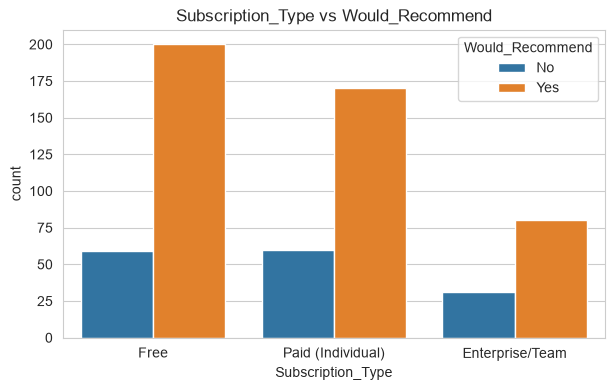

In [58]:
plt.figure(figsize=(7, 4))
sns.countplot(x=df["Subscription_Type"], hue=df["Would_Recommend"])
plt.title("Subscription_Type vs Would_Recommend")
plt.show()

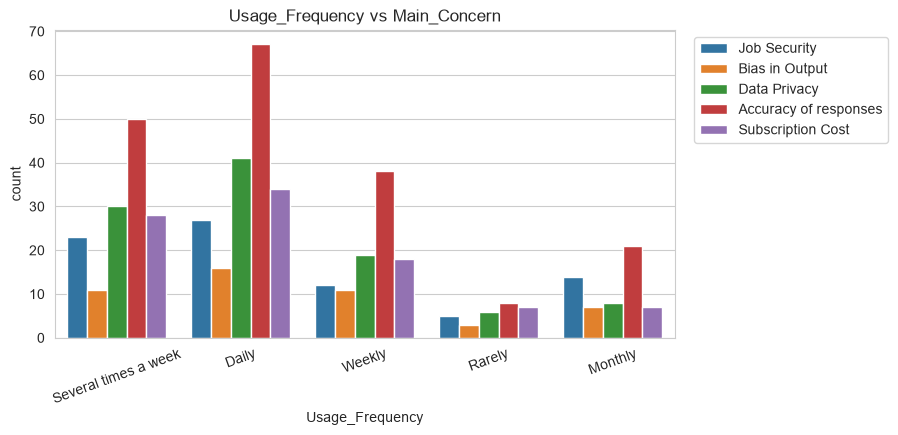

In [59]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df["Usage_Frequency"], hue=df["Main_Concern"])
plt.title("Usage_Frequency vs Main_Concern")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [60]:
#Pair plot

In [62]:
key_num = ["Hours_Per_Week", "Productivity_Gain_Percent", "Time_Saved_Hours_Per_Week",
           "Overall_Satisfaction_Score_1to10", "Trust_Level_1to10"]

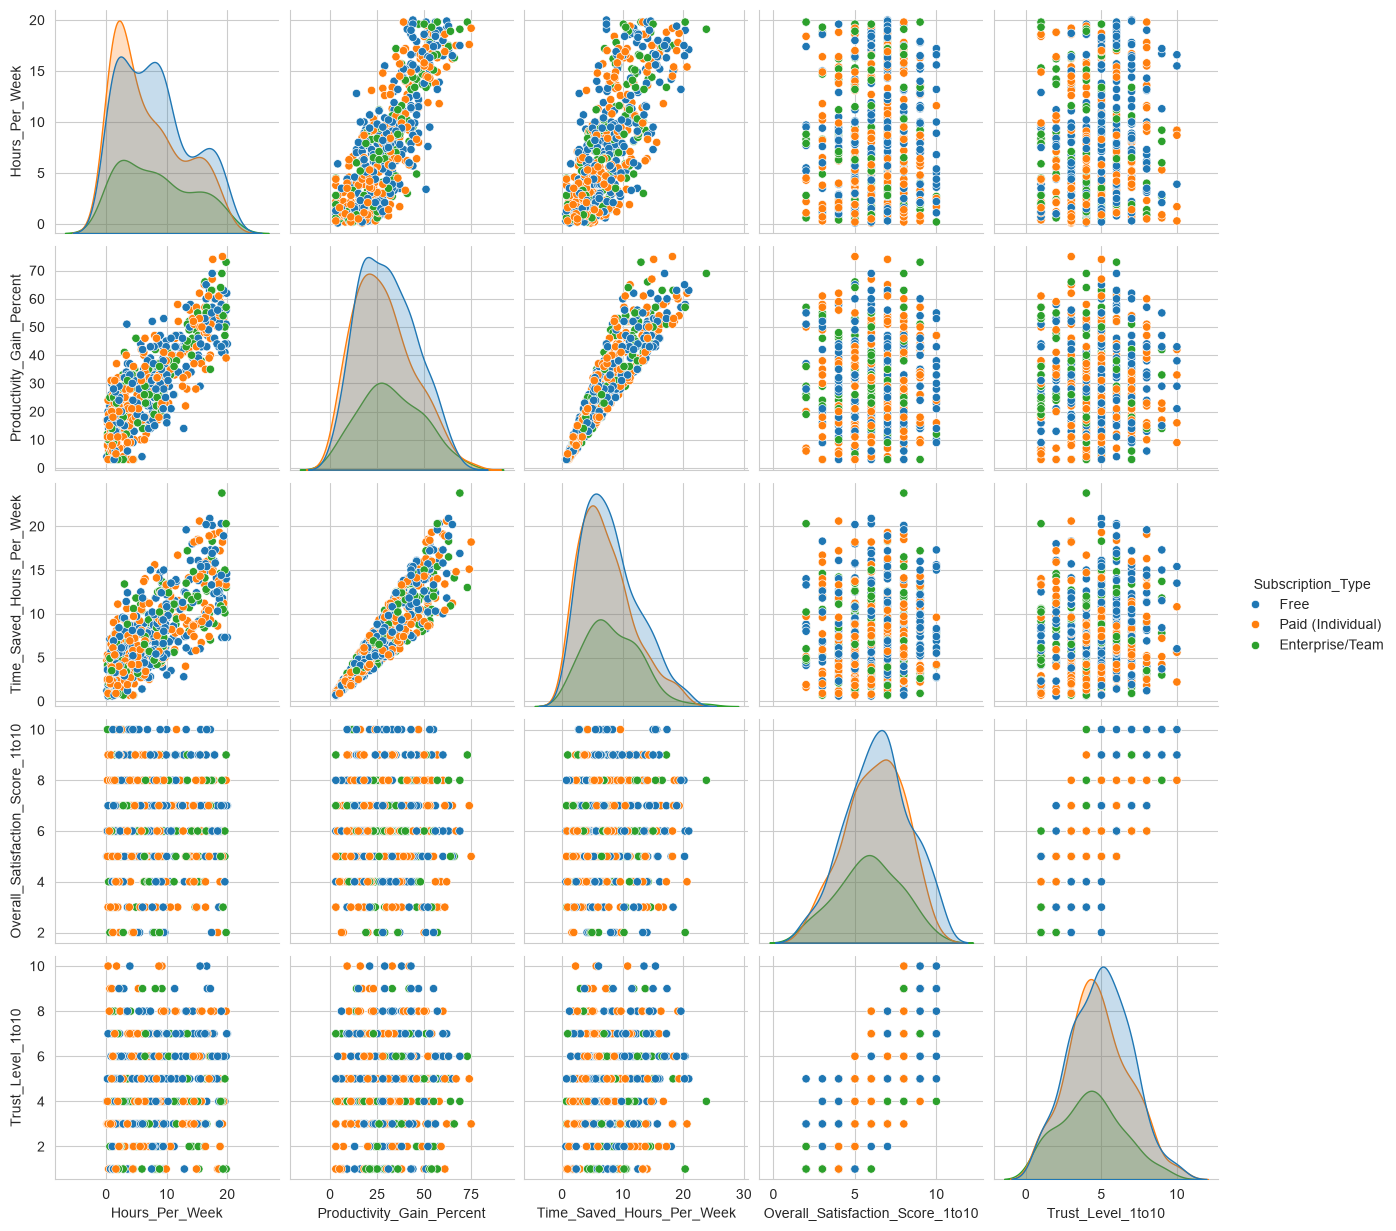

In [63]:
pairplot_cols = key_num + ["Subscription_Type"]
df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="Subscription_Type")
plt.show()

In [64]:
#Correlation heatmap

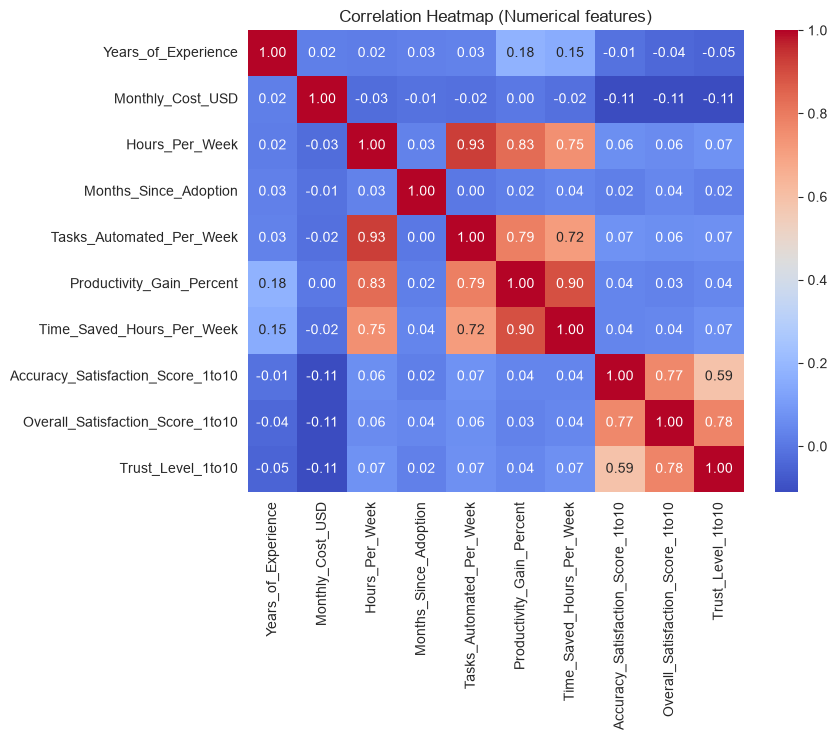

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical features)")
plt.show()

In [66]:
#Cluster map

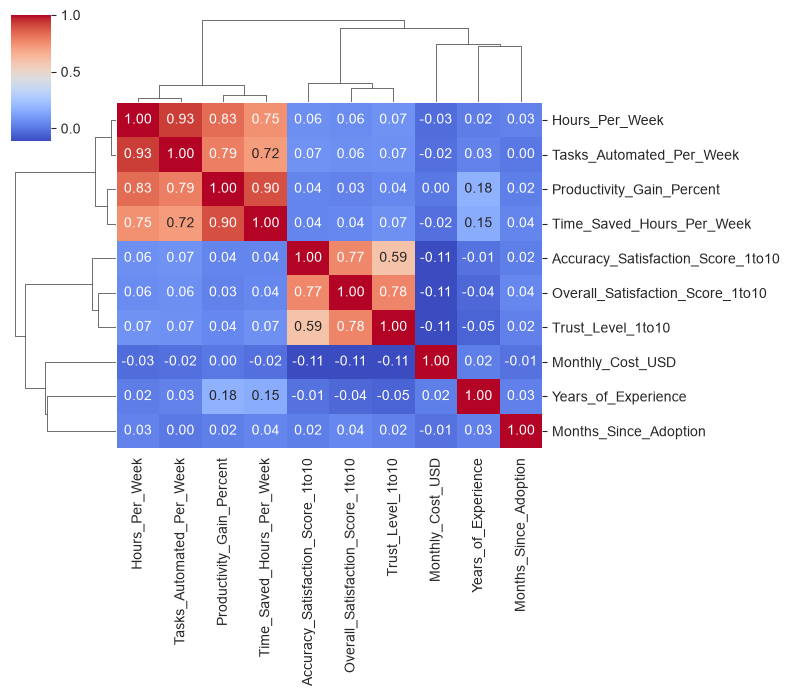

In [67]:
sns.clustermap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", figsize=(8, 7))
plt.show()

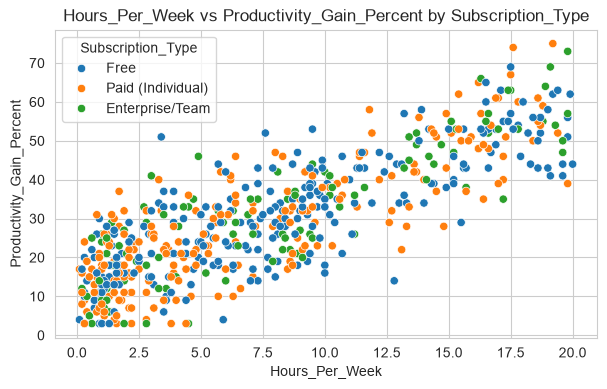

In [69]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x=df["Hours_Per_Week"], y=df["Productivity_Gain_Percent"], hue=df["Subscription_Type"])
plt.title("Hours_Per_Week vs Productivity_Gain_Percent by Subscription_Type")
plt.show()

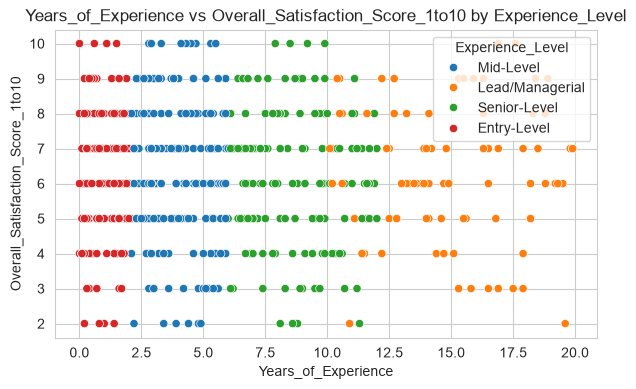

In [70]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x=df["Years_of_Experience"], y=df["Overall_Satisfaction_Score_1to10"], hue=df["Experience_Level"])
plt.title("Years_of_Experience vs Overall_Satisfaction_Score_1to10 by Experience_Level")
plt.show()

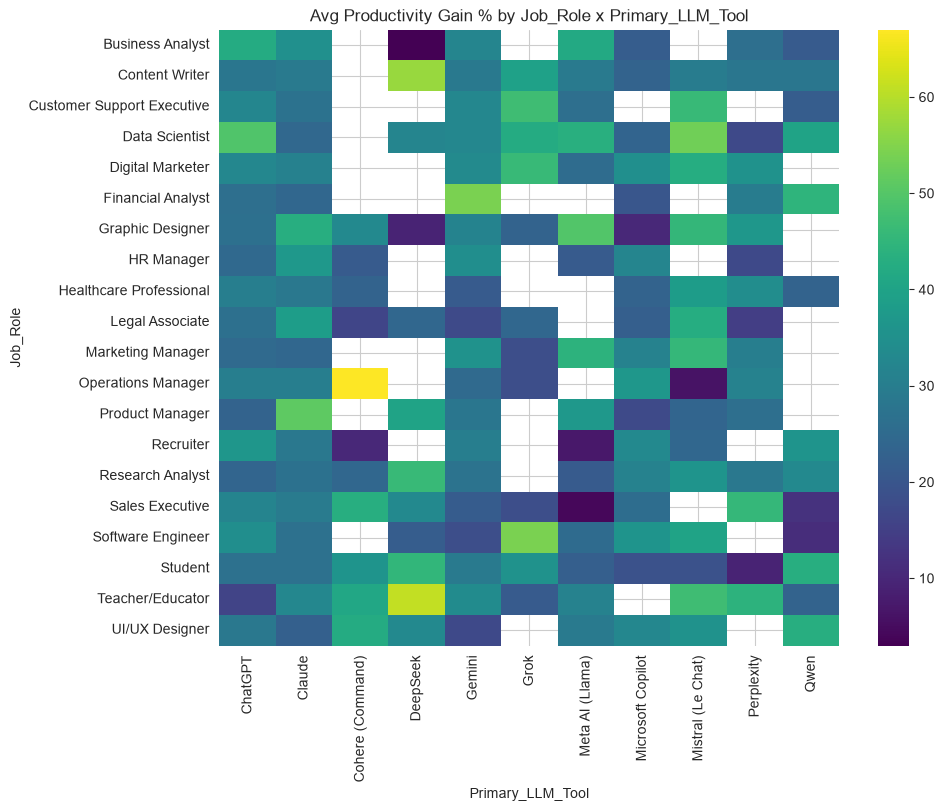

In [71]:
# average productivity gain by role and top LLM tool (pivot heatmap)
pivot = df.pivot_table(values="Productivity_Gain_Percent", index="Job_Role",
                        columns="Primary_LLM_Tool", aggfunc="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap="viridis")
plt.title("Avg Productivity Gain % by Job_Role x Primary_LLM_Tool")
plt.show()

In [72]:
#IQR method

In [73]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound, iqr

In [74]:
for col in num_cols:
    col_clean = df[col].dropna()
    lower, upper, iqr = iqr_bounds(col_clean)
    outliers_mask = (col_clean < lower) | (col_clean > upper)
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nIQR method for {col}:")
    print(f" Lower bound: {lower:.2f}, Upper bound: {upper:.2f}, IQR: {iqr:.2f}")
    print(f" Outliers: {num_outliers} / {total} ({num_outliers/total*100:.2f}%)")


IQR method for Years_of_Experience:
 Lower bound: -8.79, Upper bound: 19.71, IQR: 7.12
 Outliers: 3 / 600 (0.50%)

IQR method for Monthly_Cost_USD:
 Lower bound: -33.00, Upper bound: 55.00, IQR: 22.00
 Outliers: 0 / 600 (0.00%)

IQR method for Hours_Per_Week:
 Lower bound: -11.79, Upper bound: 25.51, IQR: 9.32
 Outliers: 0 / 600 (0.00%)

IQR method for Months_Since_Adoption:
 Lower bound: -16.00, Upper bound: 64.00, IQR: 20.00
 Outliers: 0 / 600 (0.00%)

IQR method for Tasks_Automated_Per_Week:
 Lower bound: -16.50, Upper bound: 35.50, IQR: 13.00
 Outliers: 0 / 600 (0.00%)

IQR method for Productivity_Gain_Percent:
 Lower bound: -16.50, Upper bound: 75.50, IQR: 23.00
 Outliers: 0 / 600 (0.00%)

IQR method for Time_Saved_Hours_Per_Week:
 Lower bound: -5.29, Upper bound: 20.01, IQR: 6.33
 Outliers: 7 / 600 (1.17%)

IQR method for Accuracy_Satisfaction_Score_1to10:
 Lower bound: 2.00, Upper bound: 10.00, IQR: 2.00
 Outliers: 0 / 600 (0.00%)

IQR method for Overall_Satisfaction_Score_1to1

In [75]:
#Z-score method

In [76]:
z_threshold = 3.0

for col in num_cols:
    col_clean = df[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()

    z_scores = (col_clean - mean) / std
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"{col}: {num_outliers} / {total} outliers (|Z| > {z_threshold})")

Years_of_Experience: 0 / 600 outliers (|Z| > 3.0)
Monthly_Cost_USD: 0 / 600 outliers (|Z| > 3.0)
Hours_Per_Week: 0 / 600 outliers (|Z| > 3.0)
Months_Since_Adoption: 0 / 600 outliers (|Z| > 3.0)
Tasks_Automated_Per_Week: 0 / 600 outliers (|Z| > 3.0)
Productivity_Gain_Percent: 0 / 600 outliers (|Z| > 3.0)
Time_Saved_Hours_Per_Week: 1 / 600 outliers (|Z| > 3.0)
Accuracy_Satisfaction_Score_1to10: 0 / 600 outliers (|Z| > 3.0)
Overall_Satisfaction_Score_1to10: 0 / 600 outliers (|Z| > 3.0)
Trust_Level_1to10: 0 / 600 outliers (|Z| > 3.0)


In [77]:
#Stats comparison after removing outliers (Productivity_Gain_Percent)

In [78]:
pg_clean = df["Productivity_Gain_Percent"].dropna()
pg_lower, pg_upper, pg_iqr = iqr_bounds(pg_clean)
pg_inliers = pg_clean[(pg_clean >= pg_lower) & (pg_clean <= pg_upper)]

print("Productivity_Gain_Percent stats WITH outliers:")
print(pg_clean.describe())
print("\nProductivity_Gain_Percent stats WITHOUT outliers:")
print(pg_inliers.describe())

Productivity_Gain_Percent stats WITH outliers:
count   600.000
mean     29.970
std      15.586
min       3.000
25%      18.000
50%      28.000
75%      41.000
max      75.000
Name: Productivity_Gain_Percent, dtype: float64

Productivity_Gain_Percent stats WITHOUT outliers:
count   600.000
mean     29.970
std      15.586
min       3.000
25%      18.000
50%      28.000
75%      41.000
max      75.000
Name: Productivity_Gain_Percent, dtype: float64
